# `Industrial Machine Learning on Hadoop and Spark`
## `Seminar 10: Spark Streaming`

### `Nakhodnov Maksim`
#### `Bremen, 2025`

What you will learn from this notebook:

* Streaming Data Processing
    * DStream
    * Structured Streaming

In [1]:
%pip install pyspark pyarrow sparknlp -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
from typing import Iterator

import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')

In [3]:
import pyspark.sql.types as T
import pyspark.sql.functions as F
import pyspark.sql.streaming.state
import pyspark.sql.streaming.listener

from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext
from pyspark.streaming import StreamingContext

conf = (
    SparkConf()
        .set('spark.ui.port', '4050')
        .set('spark.driver.memory', '15g')
        # The number of partitions should be set to the number of cores in local mode
        # By default it is set to 200, which is not good for local development
        # Critical for performance on small data/local mode to avoid scheduling overhead
        .set("spark.sql.shuffle.partitions", "12")
        # RocksDB
        .set(
            "spark.sql.streaming.stateStore.providerClass", 
            "org.apache.spark.sql.execution.streaming.state.RocksDBStateStoreProvider"
        )
        # Kafka + Delta Lake
        .set('spark.jars.packages', 'org.apache.spark:spark-sql-kafka-0-10_2.12:3.2.0,io.delta:delta-spark_2.12:3.3.2')
        .set("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
        .set("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
        .setMaster('local[*]')
)
sc = SparkContext(conf=conf)
spark = SparkSession(sc)

25/12/01 17:24:56 WARN Utils: Your hostname, DESKTOP-8FB26C5 resolves to a loopback address: 127.0.1.1; using 172.29.27.85 instead (on interface eth0)
25/12/01 17:24:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/maksim64/.ivy2/cache
The jars for the packages stored in: /home/maksim64/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-69f4ca13-2df4-4359-a746-443e1fa800a6;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.2.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.2.0 in central
	found org.apache.kafka#kafka-clients;2.8.0 in central
	found org.lz4#lz4-java;1.7.1 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.30 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.1 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.1 in central
	found org.apache.htrace#htrace-core4;4.1.0-incubating in central
	found commons-logging#commons-logging;1.1.3 in central
	fo

## `Legacy. DStream`

**Discretized Streams** (or **DStreams**) is the basic abstraction in Spark Streaming for continuous data streams. The stream can be an input signal coming from a source, or output data generated by executing transformations on an input stream.

**DStreams are a sequence of RDDs.**

Any operation applied to the Stream is transformed into operations on the underlying RDDs.

### `DStream — a stream of RDDs`

Analogous to `SparkContext`, which is the *entrypoint* for interacting with the cluster, `StreamingContext` is used for Streaming functionality.

Using `StreamingContext`, you can create data streams from various sources. The `batchDuration` parameter defines the time interval during which data will be collected into a batch and then processed.

In [4]:
ssc = StreamingContext(sparkContext=sc, batchDuration=2)

/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/streaming/context.py:72: FutureWarning: DStream is deprecated as of Spark 3.4.0. Migrate to Structured Streaming.
  warnings.warn(


For a test example, let's create an RDD stream from a list of RDDs:

In [5]:
rdd_queue = []
for idx in range(5):
    rdd_queue += [
        ssc.sparkContext.parallelize(
            [100 * idx + jdx for jdx in range(1, 101)], numSlices=10
        )
    ]
print(f'Number of batches with data: {len(rdd_queue)}', rdd_queue[0], rdd_queue[0].collect(), sep='\n')

Number of batches with data: 5
ParallelCollectionRDD[0] at readRDDFromFile at PythonRDD.scala:289
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


In [6]:
rdd_stream = ssc.queueStream(rdd_queue)

Apply a `map-reduce` transformation to the data stream:

In [7]:
mapped_stream = rdd_stream.map(lambda x: (x % 10, x))
reduced_stream = mapped_stream.reduceByKey(lambda a, b: a + b)

Computations in Spark Streaming are lazy. It should be noted that only output operations ([Output Operations](https://spark.apache.org/docs/latest/streaming-programming-guide.html#output-operations-on-dstreams)) act as **actions** that trigger computations, passing the result to an external system (e.g., printing to console, saving to disk, etc.).

The simplest example of Output Operations is the `pprint` method, which prints the RDD to the console:

In [8]:
reduced_stream.pprint()

However, computations only begin the moment data starts arriving from an external source. To start receiving data, you need to begin "listening" to the data source using the `start` method.

By default, the stream will continue to listen for data indefinitely. The `stop` method allows stopping the stream. However, if there is a need to wait for the completion of computations that will be stopped by *another thread*, you can use the blocking method `awaitTerminationOrTimeout`.

In [9]:
ssc.start()

# This method performs a block
# Wait for 12 seconds before releasing the block
ssc.awaitTerminationOrTimeout(timeout=12)

# Stop receiving data into the stream
ssc.stop(stopGraceFully=True, stopSparkContext=False)

-------------------------------------------
Time: 2025-12-01 17:25:26
-------------------------------------------
(0, 550)
(1, 460)
(2, 470)
(3, 480)
(4, 490)
(5, 500)
(6, 510)
(7, 520)
(8, 530)
(9, 540)

-------------------------------------------
Time: 2025-12-01 17:25:28
-------------------------------------------
(0, 1550)
(1, 1460)
(2, 1470)
(3, 1480)
(4, 1490)
(5, 1500)
(6, 1510)
(7, 1520)
(8, 1530)
(9, 1540)

-------------------------------------------
Time: 2025-12-01 17:25:30
-------------------------------------------
(0, 2550)
(1, 2460)
(2, 2470)
(3, 2480)
(4, 2490)
(5, 2500)
(6, 2510)
(7, 2520)
(8, 2530)
(9, 2540)

-------------------------------------------
Time: 2025-12-01 17:25:32
-------------------------------------------
(0, 3550)
(1, 3460)
(2, 3470)
(3, 3480)
(4, 3490)
(5, 3500)
(6, 3510)
(7, 3520)
(8, 3530)
(9, 3540)

-------------------------------------------
Time: 2025-12-01 17:25:34
-------------------------------------------
(0, 4550)
(1, 4460)
(2, 4470)
(3, 44

-------------------------------------------
Time: 2025-12-01 17:25:40
-------------------------------------------



### `Reading from a Socket`

Another way to receive data into a stream is reading from a socket:

In [10]:
ssc = StreamingContext(sparkContext=sc, batchDuration=3)

socket_stream = ssc.socketTextStream('localhost', 9999)
socket_stream

In [11]:
socket_stream.pprint()

Start a client that will send data to the stream:
```bash
nc -l 9999
```

In [12]:
ssc.start()

ssc.awaitTerminationOrTimeout(timeout=16)
ssc.stop(stopGraceFully=True, stopSparkContext=False)

-------------------------------------------
Time: 2025-12-01 17:26:09
-------------------------------------------



25/12/01 17:26:09 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:26:09 WARN BlockManager: Block input-0-1764606369600 replicated to only 0 peer(s) instead of 1 peers
25/12/01 17:26:11 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:26:11 WARN BlockManager: Block input-0-1764606370800 replicated to only 0 peer(s) instead of 1 peers
25/12/01 17:26:12 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:26:12 WARN BlockManager: Block input-0-1764606372000 replicated to only 0 peer(s) instead of 1 peers


-------------------------------------------
Time: 2025-12-01 17:26:12
-------------------------------------------
cat
dog



-------------------------------------------
Time: 2025-12-01 17:26:15
-------------------------------------------
apple



-------------------------------------------
Time: 2025-12-01 17:26:18
-------------------------------------------



25/12/01 17:26:18 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:26:18 WARN BlockManager: Block input-0-1764606378000 replicated to only 0 peer(s) instead of 1 peers


-------------------------------------------
Time: 2025-12-01 17:26:21
-------------------------------------------
cake



-------------------------------------------
Time: 2025-12-01 17:26:24
-------------------------------------------



25/12/01 17:26:24 WARN SocketReceiver: Error receiving data
java.net.SocketException: Socket closed
	at java.base/sun.nio.ch.NioSocketImpl.endRead(NioSocketImpl.java:253)
	at java.base/sun.nio.ch.NioSocketImpl.implRead(NioSocketImpl.java:332)
	at java.base/sun.nio.ch.NioSocketImpl.read(NioSocketImpl.java:355)
	at java.base/sun.nio.ch.NioSocketImpl$1.read(NioSocketImpl.java:808)
	at java.base/java.net.Socket$SocketInputStream.read(Socket.java:966)
	at java.base/sun.nio.cs.StreamDecoder.readBytes(StreamDecoder.java:287)
	at java.base/sun.nio.cs.StreamDecoder.implRead(StreamDecoder.java:330)
	at java.base/sun.nio.cs.StreamDecoder.read(StreamDecoder.java:190)
	at java.base/java.io.InputStreamReader.read(InputStreamReader.java:177)
	at java.base/java.io.BufferedReader.fill(BufferedReader.java:162)
	at java.base/java.io.BufferedReader.readLine(BufferedReader.java:329)
	at java.base/java.io.BufferedReader.readLine(BufferedReader.java:396)
	at org.apache.spark.streaming.dstream.SocketReceiver$

-------------------------------------------
Time: 2025-12-01 17:26:27
-------------------------------------------

-------------------------------------------
Time: 2025-12-01 17:26:30
-------------------------------------------



### `Word Count`

Let's implement Word Count on streaming data:

In [13]:
ssc = StreamingContext(sparkContext=sc, batchDuration=5)

counts_stream = (
    ssc
        .socketTextStream('localhost', 9999)
        .flatMap(lambda line: line.split(' '))
        .map(lambda word: (word, 1))
        .reduceByKey(lambda x, y: x + y)
)
counts_stream.pprint()

In [14]:
ssc.start()

ssc.awaitTerminationOrTimeout(timeout=25)
ssc.stop(stopGraceFully=True, stopSparkContext=False)

-------------------------------------------
Time: 2025-12-01 17:26:55
-------------------------------------------



25/12/01 17:26:57 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:26:57 WARN BlockManager: Block input-0-1764606417000 replicated to only 0 peer(s) instead of 1 peers
25/12/01 17:26:59 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:26:59 WARN BlockManager: Block input-0-1764606419000 replicated to only 0 peer(s) instead of 1 peers


-------------------------------------------
Time: 2025-12-01 17:27:00
-------------------------------------------
('cat', 1)
('apple', 2)
('dog', 1)



25/12/01 17:27:01 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:27:01 WARN BlockManager: Block input-0-1764606421400 replicated to only 0 peer(s) instead of 1 peers
25/12/01 17:27:04 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:27:04 WARN BlockManager: Block input-0-1764606424600 replicated to only 0 peer(s) instead of 1 peers
25/12/01 17:27:05 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:27:05 WARN BlockManager: Block input-0-1764606425600 replicated to only 0 peer(s) instead of 1 peers


-------------------------------------------
Time: 2025-12-01 17:27:05
-------------------------------------------
('cat', 1)
('dog', 1)
('hello', 1)



25/12/01 17:27:08 WARN RandomBlockReplicationPolicy: Expecting 1 replicas with only 0 peer/s.
25/12/01 17:27:08 WARN BlockManager: Block input-0-1764606427800 replicated to only 0 peer(s) instead of 1 peers


-------------------------------------------
Time: 2025-12-01 17:27:10
-------------------------------------------
('red', 1)
('blue', 1)



-------------------------------------------
Time: 2025-12-01 17:27:15
-------------------------------------------



25/12/01 17:27:19 ERROR ReceiverTracker: Deregistered receiver for stream 0: Stopped by driver
25/12/01 17:27:19 WARN SocketReceiver: Error receiving data
java.net.SocketException: Socket closed
	at java.base/sun.nio.ch.NioSocketImpl.endRead(NioSocketImpl.java:253)
	at java.base/sun.nio.ch.NioSocketImpl.implRead(NioSocketImpl.java:332)
	at java.base/sun.nio.ch.NioSocketImpl.read(NioSocketImpl.java:355)
	at java.base/sun.nio.ch.NioSocketImpl$1.read(NioSocketImpl.java:808)
	at java.base/java.net.Socket$SocketInputStream.read(Socket.java:966)
	at java.base/sun.nio.cs.StreamDecoder.readBytes(StreamDecoder.java:287)
	at java.base/sun.nio.cs.StreamDecoder.implRead(StreamDecoder.java:330)
	at java.base/sun.nio.cs.StreamDecoder.read(StreamDecoder.java:190)
	at java.base/java.io.InputStreamReader.read(InputStreamReader.java:177)
	at java.base/java.io.BufferedReader.fill(BufferedReader.java:162)
	at java.base/java.io.BufferedReader.readLine(BufferedReader.java:329)
	at java.base/java.io.Buffered

-------------------------------------------
Time: 2025-12-01 17:27:20
-------------------------------------------

-------------------------------------------
Time: 2025-12-01 17:27:25
-------------------------------------------



### `Online Learning`

Thanks to processing data in separate batches, DStream is well suited for online training of ML algorithms.

Let's try to train **KMeans** on streaming data. Specifically, we will cluster images of digits with a resolution of $8\times 8$:

In [15]:
import numpy as np

from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

data, labels = load_digits(return_X_y=True)
low_d_data = TSNE(n_components=2, init='pca', learning_rate=200.0).fit_transform(data)

idxs = np.arange(len(labels))

(n_samples, n_features), n_digits = data.shape, np.unique(labels).size
print(f'Number of classes: {n_digits}; number of samples: {n_samples}; number of features {n_features}')

Number of classes: 10; number of samples: 1797; number of features 64


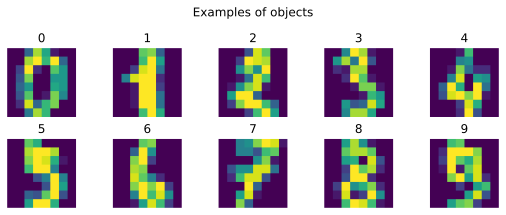

In [16]:
grid_size = np.array([2, 5])
fig, axes = plt.subplots(*grid_size, figsize=1.5 * grid_size[::-1])

for idx, ax in enumerate(axes.reshape(-1)):
    ax.imshow(data[idx].reshape(8, 8))
    ax.set_title(labels[idx])
    ax.set_axis_off()
    
fig.suptitle('Examples of objects')
fig.tight_layout()
plt.show()

The **MLLib** module is used for streaming machine learning:

In [17]:
from pyspark.mllib.linalg import Vectors
from pyspark.mllib.clustering import StreamingKMeans

Generate a data stream from our dataset:

In [18]:
ssc = StreamingContext(sparkContext=sc, batchDuration=0.001)

batch_size = 64
num_batches = 10 * len(data) // batch_size
random_generator = np.random.default_rng(43)

rdds = []
for idx in range(num_batches):
    batch_idxs = random_generator.choice(len(data), size=batch_size, replace=False)
    rdds.append(
        ssc.sparkContext.parallelize(
            list(zip(idxs[batch_idxs], labels[batch_idxs], data[batch_idxs])), numSlices=2
        )
    )
    
print(f'Number of batches with data: {len(rdds)}\n', sep='\n')
print(rdds[0], f'Number of elements in batch: {len(rdds[0].collect())}\n', sep='\n')
print('Several elements from the batch:', rdds[0].collect()[:4], sep='\n')

/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/streaming/context.py:72: FutureWarning: DStream is deprecated as of Spark 3.4.0. Migrate to Structured Streaming.
  warnings.warn(


Number of batches with data: 280

ParallelCollectionRDD[147] at readRDDFromFile at PythonRDD.scala:289
Number of elements in batch: 64

Several elements from the batch:
[(1515, 4, array([ 0.,  0.,  0., 14.,  8.,  0.,  0.,  0.,  0.,  0.,  3., 16.,  3.,
        0.,  0.,  0.,  0.,  0., 12.,  9.,  9.,  7.,  0.,  0.,  0.,  6.,
       15.,  1., 14., 11.,  6.,  0.,  0., 13., 14.,  8., 16., 16.,  7.,
        0.,  0.,  8., 16., 16., 16.,  3.,  0.,  0.,  0.,  0.,  1., 11.,
       14.,  0.,  0.,  0.,  0.,  0.,  0., 14., 14.,  0.,  0.,  0.])), (1464, 0, array([ 0.,  0.,  3., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 14., 15.,
       13.,  0.,  0.,  0.,  2., 14.,  1.,  2., 13.,  4.,  0.,  0.,  4.,
        8.,  0.,  0.,  5.,  8.,  0.,  0.,  4.,  8.,  0.,  0.,  4.,  8.,
        0.,  0.,  4., 10.,  0.,  0.,  5.,  8.,  0.,  0.,  0., 14., 11.,
       10., 14.,  5.,  0.,  0.,  0.,  4., 12., 13.,  9.,  0.,  0.])), (1662, 9, array([ 0.,  0.,  7., 15., 16., 12.,  0.,  0.,  0., 12., 16., 11., 16.,
       13., 

In [19]:
data_stream = ssc.queueStream(rdds)
data_stream

Prepare the data before feeding it to the algorithm. We need to convert the feature array into a `Vector`:

In [20]:
vectors_stream = data_stream.map(lambda x: ((x[0], x[1]), Vectors.dense(x[2])))

Define the training pipeline and a function that will perform predictions on the current batch using the current model:

In [21]:
kmeans = (
    StreamingKMeans()
        .setK(10)
        .setDecayFactor(0.9)
        .setRandomCenters(64, weight=0.5, seed=42)
)
kmeans.trainOn(vectors_stream.map(lambda x: x[1]))

predictions = kmeans.predictOnValues(vectors_stream)
predictions.saveAsTextFiles(prefix='./artifacts/kmeans-predictions/batch', suffix='txt')

In [22]:
! rm -rf ./artifacts/kmeans-predictions/
ssc.start()

# Stop training after 200 seconds, assuming the model has time to process all data
# In the general case, a more complex stopping criterion should be used to call the stop method
ssc.awaitTerminationOrTimeout(timeout=200)
ssc.stop(stopGraceFully=False, stopSparkContext=False)

25/12/01 17:27:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/01 17:27:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


In [23]:
def plot_2d_data(data, labels, title='Source Data', cmap='tab20', ax=None):
    '''
    Drawing a 2d scatter plot. 
    :param np.ndarray data: 2d array of points
    :param Union[list, np.ndarray] labels: list of labels for each point in the dataset
    :param str title: plot title
    :param str cmap: color palette
    :param ax Optional[matplotlib.axes.Axes]: axes for drawing the plot.
        If axes are not set, a new figure is created and drawn immediately.
        Otherwise, the plot is added to the existing axes. The figure is not drawn.
    '''
    unique_labels, labels_inv = np.unique(labels, return_inverse=True)
    n_clusters = len(unique_labels)
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    else:
        fig = None
        
    scatter = ax.scatter(
        data[:, 0], data[:, 1], c=labels_inv, 
        cmap=plt.get_cmap(cmap, n_clusters)
    )

    cbar = plt.colorbar(scatter, label='Cluster number', ax=ax)
    cbar.set_ticks((np.arange(n_clusters) + 0.5) * (n_clusters - 1) / n_clusters)
    cbar.set_ticklabels(unique_labels)
    
    ax.set_title(title)
    ax.grid(True)
    
    if fig is not None:
        fig.tight_layout()
        plt.show()

25/12/01 17:31:21 ERROR SparkHadoopWriter: Aborting job job_202512011731211412954300449954011_11553.
java.io.InterruptedIOException: java.lang.InterruptedException
	at org.apache.hadoop.util.Shell.runCommand(Shell.java:1010)
	at org.apache.hadoop.util.Shell.run(Shell.java:900)
	at org.apache.hadoop.util.Shell$ShellCommandExecutor.execute(Shell.java:1212)
	at org.apache.hadoop.util.Shell.execCommand(Shell.java:1306)
	at org.apache.hadoop.util.Shell.execCommand(Shell.java:1288)
	at org.apache.hadoop.fs.RawLocalFileSystem.setPermission(RawLocalFileSystem.java:978)
	at org.apache.hadoop.fs.RawLocalFileSystem$LocalFSFileOutputStream.<init>(RawLocalFileSystem.java:324)
	at org.apache.hadoop.fs.RawLocalFileSystem$LocalFSFileOutputStream.<init>(RawLocalFileSystem.java:294)
	at org.apache.hadoop.fs.RawLocalFileSystem.createOutputStreamWithMode(RawLocalFileSystem.java:439)
	at org.apache.hadoop.fs.RawLocalFileSystem.create(RawLocalFileSystem.java:428)
	at org.apache.hadoop.fs.RawLocalFileSystem.

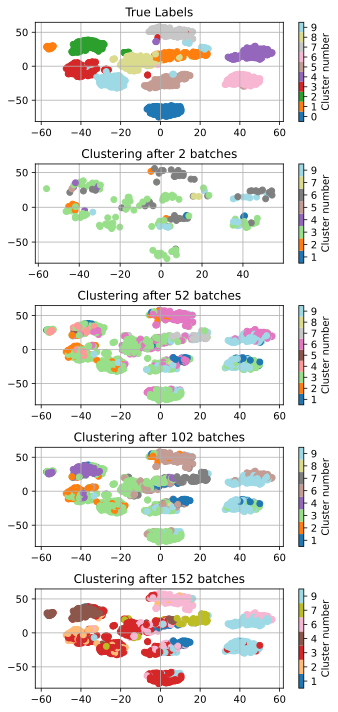

In [24]:
batch_files = sorted(os.listdir('./artifacts/kmeans-predictions/'))

grid_size = np.array([5, 1])
fig, axes = plt.subplots(*grid_size, figsize=np.array([5, 2]) * grid_size[::-1])

plot_2d_data(low_d_data, labels, ax=axes[0], title='True Labels')

ax_idx = 0
predictions = -np.ones_like(labels)
for ts, batch_predictions_path in enumerate(batch_files):
    for path in glob.glob(os.path.join('./artifacts/kmeans-predictions/', batch_predictions_path, '*')):
        if os.path.isfile(path) and not path.endswith('_SUCCESS'):
            with open(path, 'r') as file:
                for line in file:
                    ((idx, label), cluster) = eval(line)
                    predictions[idx] = cluster                    
             
    if ts % 50 == 2:
        ax_idx += 1
        if ax_idx == len(axes):
            break   
            
        plot_2d_data(
            low_d_data[predictions != -1], predictions[predictions != -1], 
            title=f'Clustering after {ts} batches', ax=axes[ax_idx]
        )
            
fig.tight_layout()
plt.show()

## `Structured Streaming`

### `Introduction`

Spark Streaming is a fairly low-level, mostly *stateless* approach to stream data processing. The modern alternative is **Structured Streaming**. This library holds the same position relative to Spark Streaming as the DataFrame API does to the RDD API.

Structured Streaming allows you to work with data streams in the same way as with fixed-size tables. In this paradigm, a data stream is represented as an infinite table. Computations on such an infinite table occur by a trigger at specific moments in time. Note that at a fixed moment in time, only a finite table needs to be processed. Structured Streaming allows running queries on infinite tables by efficiently updating internal state when transitioning from one time moment to another.

Let's consider a Word Count example using Structured Streaming.

Create a table that uses a socket as a data source:

In [25]:
lines_df = (
    spark
        .readStream
        .format('socket')
        .option('host', 'localhost')
        .option('port', 9999)
        .load()
)
lines_df

25/12/01 17:32:02 WARN TextSocketSourceProvider: The socket source should not be used for production applications! It does not support recovery.


DataFrame[value: string]

In [26]:
words_df = lines_df.select(
   F.explode(
       F.split(lines_df.value, ' ')
   ).alias('word')
)

counts_df = words_df.groupBy('word').count()

In [27]:
counts_df.explain(extended=True)
counts_df.printSchema()

== Parsed Logical Plan ==
'Aggregate ['word], ['word, count(1) AS count#7L]
+- Project [word#3]
   +- Generate explode(split(value#0,  , -1)), false, [word#3]
      +- StreamingRelationV2 org.apache.spark.sql.execution.streaming.sources.TextSocketSourceProvider@1d3f60b3, socket, org.apache.spark.sql.execution.streaming.sources.TextSocketTable@4e3db412, [host=localhost, port=9999], [value#0]

== Analyzed Logical Plan ==
word: string, count: bigint
Aggregate [word#3], [word#3, count(1) AS count#7L]
+- Project [word#3]
   +- Generate explode(split(value#0,  , -1)), false, [word#3]
      +- StreamingRelationV2 org.apache.spark.sql.execution.streaming.sources.TextSocketSourceProvider@1d3f60b3, socket, org.apache.spark.sql.execution.streaming.sources.TextSocketTable@4e3db412, [host=localhost, port=9999], [value#0]

== Optimized Logical Plan ==
Aggregate [word#3], [word#3, count(1) AS count#7L]
+- Generate explode(split(value#0,  , -1)), [0], false, [word#3]
   +- StreamingRelationV2 org.apac

**Output Modes**

Just like in Spark Streaming, output operations act as actions.

There are different [output modes](https://spark.apache.org/docs/latest/structured-streaming-programming-guide.html#output-modes):
* **Complete mode** — the entire result table is outputted
* **Append mode** — only new rows in the result table are outputted
* **Update mode** — only rows that were updated in the result table are outputted

It should be noted that not all output modes are compatible with all transformations in the computation graph.

In this example, we will output the result table in *update* mode at every trigger firing.

**State checkpointing**

Since we have stateful stream processing in this example (due to the groupby operation), the question arises: where is the state stored, and what happens if an error occurs during computation?

Unlike static table processing, caching does not make sense here, and recalculating lost data is not always possible because the input stream might be "non-rewindable" (e.g., reading from a socket). To avoid losing state, checkpointing parameters must be specified when defining the output stream:

In [ ]:
counts_query = (
    counts_df
        .writeStream
        .queryName('counts')
        .outputMode('update')
        .option("checkpointLocation", "./artifacts/checkpoints/counts")
        .format('console')
).start()
counts_query

25/12/01 17:32:18 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+----+-----+
|word|count|
+----+-----+
+----+-----+

-------------------------------------------
Batch: 1
-------------------------------------------
+-----+-----+
| word|count|
+-----+-----+
|apple|    1|
|  cat|    1|
|  dog|    1|
+-----+-----+

-------------------------------------------
Batch: 2
-------------------------------------------
+----+-----+
|word|count|
+----+-----+
| cat|    2|
+----+-----+

-------------------------------------------
Batch: 3
-------------------------------------------
+-----+-----+
| word|count|
+-----+-----+
|apple|    2|
+-----+-----+

-------------------------------------------
Batch: 4
-------------------------------------------
+-----+-----+
| word|count|
+-----+-----+
|hello|    1|
+-----+-----+

-------------------------------------------
Batch: 5
-------------------------------------------
+----+-----+
|word|count|
+----+-----+
| how|    1|
| you|

25/12/01 17:32:46 WARN TextSocketMicroBatchStream: Stream closed by localhost:9999


In [29]:
counts_query.stop()

Let's look at an example with a table read from the hard drive.

We will use a dataset with data from wearable devices [Heterogeneity Activity Recognition Data Set](http://archive.ics.uci.edu/ml/datasets/heterogeneity+activity+recognition):

In [ ]:
! rm -rf './data/Activity recognition exp.zip' './data/activity-data'
! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00344/Activity%20recognition%20exp.zip -O './data/Activity recognition exp.zip'
! unzip -j './data/Activity recognition exp.zip' 'data/Activity recognition exp/*' -d data/activity-data

! head ./data/activity-data/Phones_accelerometer.csv > ./data/activity-data/Sample_data.csv

First, let's look at a part of this data as a static table:

In [30]:
static_phone_activity_df = (
    spark
        .read
        .option('inferSchema', True)
        .option('header', True)
        .csv('data/activity-data/Phones_accelerometer.csv')
)
static_phone_activity_df.printSchema()

root
 |-- Index: integer (nullable = true)
 |-- Arrival_Time: long (nullable = true)
 |-- Creation_Time: long (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- z: double (nullable = true)
 |-- User: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Device: string (nullable = true)
 |-- gt: string (nullable = true)



In [31]:
static_phone_activity_df.sample(5e-7, seed=43).toPandas()

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,14545,1424696715942,1424698561997492480,-5.673569,0.548065,7.885208,a,nexus4,nexus4_2,stand
1,143658,1424786383679,140643324282000,-0.603339,1.762132,5.544971,b,s3,s3_1,null
2,171846,1424778428268,2810354904000,-0.829591,0.148441,9.103952,i,s3mini,s3mini_1,bike
3,71702,1424777626240,3296251996000,-2.911313,-1.379043,11.951706,i,samsungold,samsungold_1,stairsdown


Now let's represent the data as a stream. Spark can read new files from a specified directory and process them in streaming mode:

In [32]:
streaming_activity_df = (
    spark
        .readStream
        .schema(static_phone_activity_df.schema)
        .option('header', True)
        .option('maxFilesPerTrigger', 1)
        .csv('./data/activity-data/*.csv')
)

Let's make a query that counts the number of events of a specified type up to the current moment in time:

In [33]:
activity_counts_df = (
    streaming_activity_df
        .groupBy('gt')
        .count()
)

In [ ]:
activity_query = (
    activity_counts_df
        .writeStream
        .queryName('activity_counts')
        .outputMode('complete')
        .option("checkpointLocation", "./artifacts/checkpoints/activity_counts")
        .format('console')
        .start()
)

25/12/01 17:33:12 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|1783200|
|       sit|1991919|
|  stairsup|1782010|
|stairsdown|1615896|
|      bike|1845557|
|      walk|2192401|
|     stand|1851492|
+----------+-------+



-------------------------------------------
Batch: 1
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|3652827|
|       sit|4210420|
|  stairsup|3666316|
|stairsdown|3289729|
|      bike|3757287|
|      walk|4542830|
|     stand|3875698|
+----------+-------+

-------------------------------------------
Batch: 2
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|4173184|
|       sit|4634415|
|  stairsup|4140070|
|stairsdown|3776105|
|      bike|4392817|
|      walk|5092591|
|     stand|4326887|
+----------+-------+

-------------------------------------------
Batch: 3
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|4643613|
|       sit|5053949|
|  stairsup|4586093|
|stairsdown|4204346|
|      bike|4915489|
|      walk|5580900|
|     stand|4757110|
+----------+-------+

-------------

In [35]:
activity_query.stop()

Let's compare the output with other output modes:

In [ ]:
activity_update_query = (
    activity_counts_df
        .writeStream
        .queryName('activity_counts_update')
        .outputMode('update')
        .option("checkpointLocation", "./artifacts/checkpoints/activity_counts_update")
        .format('console')
        .start()
)

25/12/01 17:33:36 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|1783200|
|       sit|1991919|
|  stairsup|1782010|
|stairsdown|1615896|
|      bike|1845557|
|      walk|2192401|
|     stand|1851492|
+----------+-------+



-------------------------------------------
Batch: 1
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|3652827|
|       sit|4210420|
|  stairsup|3666316|
|stairsdown|3289729|
|      bike|3757287|
|      walk|4542830|
|     stand|3875698|
+----------+-------+

-------------------------------------------
Batch: 2
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|4173184|
|       sit|4634415|
|  stairsup|4140070|
|stairsdown|3776105|
|      bike|4392817|
|      walk|5092591|
|     stand|4326887|
+----------+-------+



-------------------------------------------
Batch: 3
-------------------------------------------
+----------+-------+
|        gt|  count|
+----------+-------+
|      null|4643613|
|       sit|5053949|
|  stairsup|4586093|
|stairsdown|4204346|
|      bike|4915489|
|      walk|5580900|
|     stand|4757110|
+----------+-------+

-------------------------------------------
Batch: 4
-------------------------------------------
+-----+-------+
|   gt|  count|
+-----+-------+
|stand|4757119|
+-----+-------+



In [37]:
activity_update_query.stop()

It is obvious from the query semantics that the *append* mode cannot be used here:

In [38]:
try:
    activity_append_query = (
        activity_counts_df
            .writeStream
            .queryName('activity_counts_append')
            .outputMode('append')
            .option("checkpointLocation", "./artifacts/checkpoints/activity_counts_append")
            .format('console')
            .start()
    )
except Exception as e:
    print(e)

Append output mode not supported when there are streaming aggregations on streaming DataFrames/DataSets without watermark;
Aggregate [gt#154], [gt#154, count(1) AS count#176L]
+- StreamingRelation DataSource(org.apache.spark.sql.SparkSession@7e5b9d3c,csv,List(),Some(StructType(StructField(Index,IntegerType,true),StructField(Arrival_Time,LongType,true),StructField(Creation_Time,LongType,true),StructField(x,DoubleType,true),StructField(y,DoubleType,true),StructField(z,DoubleType,true),StructField(User,StringType,true),StructField(Model,StringType,true),StructField(Device,StringType,true),StructField(gt,StringType,true))),List(),None,Map(header -> true, maxFilesPerTrigger -> 1, path -> ./data/activity-data/*.csv),None), FileSource[./data/activity-data/*.csv], [Index#145, Arrival_Time#146L, Creation_Time#147L, x#148, y#149, z#150, User#151, Model#152, Device#153, gt#154]



25/12/01 17:33:56 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Let's look at an example using aggregation. Compute the average coordinates grouped by (*event type*, *phone model*):

In [ ]:
gt_model_stats_query = (
    streaming_activity_df
        .cube('gt', 'model').avg()
        .drop('avg(Arrival_time)')
        .drop('avg(Creation_Time)')
        .drop('avg(Index)')
    
        .writeStream
        .queryName('gt_model_stats')
        .outputMode('complete')
        .option("checkpointLocation", "./artifacts/checkpoints/gt_model_stats")
        .format('console')
        .start()
)

25/12/01 17:34:01 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+----------+----------+--------------------+--------------------+-----------------+
|        gt|     model|              avg(x)|              avg(y)|           avg(z)|
+----------+----------+--------------------+--------------------+-----------------+
|      NULL|    nexus4| -1.8586523317319892| 0.05477199767644232| 9.15950009672931|
|  stairsup|samsungold| -3.1927193124646225|-0.05133944122085759|8.500741961184367|
|       sit|    s3mini|   3.573051556331693|  0.5469890436222271|8.169043345236462|
|      bike|    s3mini|-0.38061769919708743|0.015550321028655768|8.945381420138668|
|      NULL|samsungold| -1.3787408903197247|0.054975290115097025|9.001901888897402|
|stairsdown|      NULL|  -3.216160500387074| 0.19863535125844756|8.869203911878603|
|      NULL|        s3| -2.1577880911047393|  0.3275605958868292| 8.65173180888026|
|      NULL|      NULL| -1.7045786645373775| 0.1595409114233623

-------------------------------------------
Batch: 1
-------------------------------------------
+----------+----------+--------------------+--------------------+------------------+
|        gt|     model|              avg(x)|              avg(y)|            avg(z)|
+----------+----------+--------------------+--------------------+------------------+
|      NULL|    nexus4| -0.9290848232433536| 0.02437835288521712| 4.574675281721529|
|  stairsup|samsungold| -3.1927193124646225|-0.05133944122085759| 8.500741961184367|
|       sit|    s3mini|  1.7796468535532988| 0.26806412777539523| 4.080838276805233|
|      bike|    s3mini|-0.19837130254160404|0.001546135208933...|     4.42881098178|
|      NULL|samsungold| -1.3787408903197247|0.054975290115097025| 9.001901888897402|
|stairsdown|      NULL| -1.5699935480938476|  0.0804991911177251|  4.40968922534347|
|      NULL|        s3| -0.7017317650200728| 0.09962765660820501|2.8368664340344587|
|      NULL|      NULL| -0.8231057452257414|  0.07231

-------------------------------------------
Batch: 2
-------------------------------------------
+----------+----------+--------------------+--------------------+------------------+
|        gt|     model|              avg(x)|              avg(y)|            avg(z)|
+----------+----------+--------------------+--------------------+------------------+
|      NULL|    nexus4| -0.9290848232433536| 0.02437835288521712| 4.574675281721529|
|  stairsup|samsungold| -3.1927193124646225|-0.05133944122085759| 8.500741961184367|
|       sit|    s3mini|  1.7796468535532988| 0.26806412777539523| 4.080838276805233|
|      bike|    s3mini|-0.19837130254160404|0.001546135208933...|     4.42881098178|
|      NULL|samsungold| -1.3787408903197247|0.054975290115097025| 9.001901888897402|
|stairsdown|      NULL|    -1.4460010557583|-0.18441870003516334|3.9468721322907028|
|     stand|      gear| 0.47822169631363765|  -2.572857266856428|1.9784259949685392|
|      NULL|        s3| -0.7017317650200728| 0.099627

-------------------------------------------
Batch: 3
-------------------------------------------
+----------+----------+--------------------+--------------------+-------------------+
|        gt|     model|              avg(x)|              avg(y)|             avg(z)|
+----------+----------+--------------------+--------------------+-------------------+
|      NULL|    nexus4| -0.9290848232433536| 0.02437835288521712|  4.574675281721529|
|  stairsup|samsungold| -3.1927193124646225|-0.05133944122085759|  8.500741961184367|
|       sit|    s3mini|  1.7796468535532988| 0.26806412777539523|  4.080838276805233|
|      bike|    s3mini|-0.19837130254160404|0.001546135208933...|      4.42881098178|
|      NULL|samsungold| -1.3787408903197247|0.054975290115097025|  9.001901888897402|
|stairsdown|      NULL| -1.2953707589466252|-0.16495940231277978| 3.5470107395359562|
|     stand|      gear|  0.2520608231178629| -1.3071719491567255| 0.9654559539163472|
|      NULL|        s3| -0.7017317650200728

-------------------------------------------
Batch: 4
-------------------------------------------
+----------+----------+--------------------+--------------------+-------------------+
|        gt|     model|              avg(x)|              avg(y)|             avg(z)|
+----------+----------+--------------------+--------------------+-------------------+
|      NULL|    nexus4| -0.9290884552387619|0.024378809592868467|  4.574677847957402|
|  stairsup|samsungold| -3.1927193124646225|-0.05133944122085759|  8.500741961184367|
|       sit|    s3mini|  1.7796468535532988| 0.26806412777539523|  4.080838276805233|
|      bike|    s3mini|-0.19837130254160404|0.001546135208933...|      4.42881098178|
|      NULL|samsungold| -1.3787408903197247|0.054975290115097025|  9.001901888897402|
|stairsdown|      NULL| -1.2953707589466252|-0.16495940231277978| 3.5470107395359562|
|     stand|      gear|  0.2520608231178629| -1.3071719491567255| 0.9654559539163472|
|      NULL|        s3| -0.7017317650200728

In [40]:
gt_model_stats_query.stop()

### `Triggers`

If a stream processes a batch every second, then over a year, millions of files of a few kilobytes are created. This kills reading performance.

To balance batch size and IO volume, you can use triggers. This parameter controls how close Structured Streaming is to online data processing:

1. **once** (<span style="color:red">Deprecated</span>): processes all data available at the moment the query starts and the stream terminates. Can cause OOM.
2. **availableNow**: all data available at the moment is processed (possibly in multiple batches) and the stream terminates. Instead of keeping the cluster running 24/7 and generating small files, we start the stream once an hour. It reads everything that has accumulated, processes it as a batch, saves the checkpoint, and shuts down.
3. **processingTime**: every interval, the current mini-batch is sent for processing. When intermediate files accumulate, garbage collection may be required periodically.
4. **continuous**: mode with reduced latency. At-least-once guarantee. Upon error, the stream stops.


The `once` trigger allows processing only one batch, but it has issues reading from file storage. Let's save our table to a suitable format (Delta Lake):

In [41]:
delta_query = (
    streaming_activity_df
        .writeStream
        .queryName('gt_model_stats_delta')
        .option("checkpointLocation", "./artifacts/checkpoints/gt_model_stats_delta")
        .format("delta")
        .outputMode("append")
        .start("artifacts/activity_delta")
)

25/12/01 17:34:42 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


25/12/01 17:34:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [42]:
delta_query.stop()

In [43]:
streaming_activity_delta_df = (
    spark
        .readStream
        .format("delta")
        .option("startingVersion", "1")
        .option('maxFilesPerTrigger', 10)
        .load("artifacts/activity_delta")
)

In [ ]:
gt_model_stats_once_query = (
    streaming_activity_delta_df
        .cube('gt', 'model').avg()
        .drop('avg(Arrival_time)')
        .drop('avg(Creation_Time)')
        .drop('avg(Index)')
    
        .writeStream
        .trigger(once=True)
        .queryName('gt_model_stats_once')
        .outputMode('complete')
        .option("checkpointLocation", "./artifacts/checkpoints/gt_model_stats_once")

        .format('console')
        .start()
)

25/12/01 17:35:31 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


25/12/01 17:35:31 WARN MicroBatchExecution: The read limit MaxFiles: 10 for DeltaSource[file:/mnt/c/Users/nahod/Documents/CodeBlocks/MSU/Hadoop/Industrial-Machine-Learning-on-Hadoop-and-Spark/Seminars/Seminar 10/artifacts/activity_delta] is ignored when Trigger.Once is used.


-------------------------------------------
Batch: 0
-------------------------------------------
+----------+-------+--------------------+--------------------+--------------------+
|        gt|  model|              avg(x)|              avg(y)|              avg(z)|
+----------+-------+--------------------+--------------------+--------------------+
|      NULL| nexus4|4.708039791048006E-4|-0.00601422752343865|-0.01012162735338...|
|       sit| s3mini|-0.01399054827101...|-0.01089697932358...|-0.00789724714306...|
|      bike| s3mini|-0.01615478724317...|-0.01245575446620...|-0.08701891379487414|
|stairsdown|   NULL| -0.0962761424639539| -0.3919413057363536| 0.22451632843440678|
|     stand|   gear| 0.25206082311788036| -1.3071719491567309|  0.9654559539163525|
|      NULL|     s3|0.009835090531972665|-0.01176193867987...|-0.00482684122753...|
|      NULL|lgwatch| -0.4841089221344408|  -1.289741145878531|  1.0370157082689133|
|      NULL|   NULL|-0.07799296345522365|-0.43428015784610324| 

In [45]:
gt_model_stats_once_query.stop()

Let's look at an example using the `availableNow` trigger:

In [46]:
gt_model_stats_availableNow_query = (
    streaming_activity_delta_df
        .cube('gt', 'model').avg()
        .drop('avg(Arrival_time)')
        .drop('avg(Creation_Time)')
        .drop('avg(Index)')
    
        .writeStream
        .trigger(availableNow=True)
        .queryName('gt_model_stats_availableNow')
        .outputMode('complete')
        .option("checkpointLocation", "./artifacts/checkpoints/gt_model_stats_availableNow")

        .format('console')
        .start()
)

25/12/01 17:36:31 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+----------+------+--------------------+--------------------+--------------------+
|        gt| model|              avg(x)|              avg(y)|              avg(z)|
+----------+------+--------------------+--------------------+--------------------+
|      NULL|nexus4|0.002335333659500083|-0.00565864380284...|-0.00814849650968...|
|       sit|s3mini|-0.01497806644480...|-0.01135374595637...|-0.00665133040407...|
|      bike|s3mini|-0.03384769647679889|-0.00241227363949...|-0.07304449163483877|
|stairsdown|  NULL| -0.0227012665295327|-0.02999716282659...| 0.20018497367419646|
|      NULL|    s3| 0.01132400642145847|-0.01273585131109...|1.209419076239319...|
|      NULL|  NULL|0.005126696289965...|-0.00929815627112...|-0.00566744004314...|
|      null|    s3|0.004094882477762767|-0.00889168774735...|0.012028825992838419|
|  stairsup|s3mini| 0.17236432683530206|-0.03377294952761159| -0.13111415

-------------------------------------------
Batch: 3
-------------------------------------------
+----------+-------+--------------------+--------------------+--------------------+
|        gt|  model|              avg(x)|              avg(y)|              avg(z)|
+----------+-------+--------------------+--------------------+--------------------+
|      NULL| nexus4|4.794084516906679E-4|-0.00601518476618...|-0.01013337144277...|
|       sit| s3mini|-0.01399054827101...|-0.01089697932358...|-0.00789724714306...|
|      bike| s3mini|-0.01615478724317...|-0.01245575446620...|-0.08701891379487407|
|stairsdown|   NULL|-0.11738506393386977| -0.4323450713254667|  0.2418017209340301|
|     stand|   gear|  0.2982574475072008| -1.5738819519463156|   1.179176838366118|
|      NULL|     s3| 0.00983509053197122|-0.01176193867987...|-0.00482684122753...|
|      NULL|lgwatch| -0.6273818353569944| -1.6654096829938836|  1.3393004226084329|
|      NULL|   NULL|-0.08536243788637794|-0.47048759096564424| 

-------------------------------------------
Batch: 4
-------------------------------------------
+----------+-------+--------------------+--------------------+--------------------+
|        gt|  model|              avg(x)|              avg(y)|              avg(z)|
+----------+-------+--------------------+--------------------+--------------------+
|      NULL| nexus4|4.708039791039913E-4|-0.00601422752343779|-0.01012162735338177|
|       sit| s3mini|-0.01399054827101...|-0.01089697932358...|-0.00789724714306...|
|      bike| s3mini|-0.01615478724317...|-0.01245575446620...|-0.08701891379487407|
|stairsdown|   NULL|-0.09627614246392133|-0.39194130573634667| 0.22451632843441063|
|     stand|   gear|  0.2520608231178629| -1.3071719491567253|  0.9654559539163474|
|      NULL|     s3| 0.00983509053197122|-0.01176193867987...|-0.00482684122753...|
|      NULL|lgwatch|-0.48410892213466516| -1.2897411458787749|  1.0370157082688762|
|      NULL|   NULL|-0.07799296345525444|-0.43428015784621404| 

In [47]:
gt_model_stats_availableNow_query.stop()

In [48]:
gt_model_stats_processingTime_query = (
    streaming_activity_delta_df
        .cube('gt', 'model').avg()
        .drop('avg(Arrival_time)')
        .drop('avg(Creation_Time)')
        .drop('avg(Index)')
    
        .writeStream
        .trigger(processingTime='5 seconds')
        .queryName('gt_model_stats_processingTime')
        .outputMode('complete')
        .option("checkpointLocation", "./artifacts/checkpoints/gt_model_stats_processingTime")

        .format('console')
        .start()
)

25/12/01 17:37:04 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+----------+------+--------------------+--------------------+--------------------+
|        gt| model|              avg(x)|              avg(y)|              avg(z)|
+----------+------+--------------------+--------------------+--------------------+
|      NULL|nexus4|0.002335333659500083|-0.00565864380284...|-0.00814849650968...|
|       sit|s3mini|-0.01497806644480...|-0.01135374595637...|-0.00665133040407...|
|      bike|s3mini|-0.03384769647679889|-0.00241227363949...|-0.07304449163483877|
|stairsdown|  NULL| -0.0227012665295327|-0.02999716282659...| 0.20018497367419646|
|      NULL|    s3| 0.01132400642145847|-0.01273585131109...|1.209419076239319...|
|      NULL|  NULL|0.005126696289965...|-0.00929815627112...|-0.00566744004314...|
|      null|    s3|0.004094882477762767|-0.00889168774735...|0.012028825992838419|
|  stairsup|s3mini| 0.17236432683530206|-0.03377294952761159| -0.13111415

-------------------------------------------
Batch: 3
-------------------------------------------
+----------+-------+--------------------+--------------------+--------------------+
|        gt|  model|              avg(x)|              avg(y)|              avg(z)|
+----------+-------+--------------------+--------------------+--------------------+
|      NULL| nexus4|4.794084516906679E-4|-0.00601518476618...|-0.01013337144277...|
|       sit| s3mini|-0.01399054827101...|-0.01089697932358...|-0.00789724714306...|
|      bike| s3mini|-0.01615478724317...|-0.01245575446620...|-0.08701891379487407|
|stairsdown|   NULL|-0.11738506393386977| -0.4323450713254667|  0.2418017209340301|
|     stand|   gear|  0.2982574475072008| -1.5738819519463156|   1.179176838366118|
|      NULL|     s3| 0.00983509053197122|-0.01176193867987...|-0.00482684122753...|
|      NULL|lgwatch| -0.6273818353569944| -1.6654096829938836|  1.3393004226084329|
|      NULL|   NULL|-0.08536243788637794|-0.47048759096564424| 

-------------------------------------------
Batch: 4
-------------------------------------------
+----------+-------+--------------------+--------------------+--------------------+
|        gt|  model|              avg(x)|              avg(y)|              avg(z)|
+----------+-------+--------------------+--------------------+--------------------+
|      NULL| nexus4|4.708039791039913E-4|-0.00601422752343779|-0.01012162735338177|
|       sit| s3mini|-0.01399054827101...|-0.01089697932358...|-0.00789724714306...|
|      bike| s3mini|-0.01615478724317...|-0.01245575446620...|-0.08701891379487407|
|stairsdown|   NULL|-0.09627614246392133|-0.39194130573634667| 0.22451632843441063|
|     stand|   gear|  0.2520608231178629| -1.3071719491567253|  0.9654559539163474|
|      NULL|     s3| 0.00983509053197122|-0.01176193867987...|-0.00482684122753...|
|      NULL|lgwatch|-0.48410892213466516| -1.2897411458787749|  1.0370157082688762|
|      NULL|   NULL|-0.07799296345525444|-0.43428015784621404| 

In [49]:
gt_model_stats_processingTime_query.stop()

### `Window Operations`

Now let's see how to work with event times. Create a column with activity time in timestamp format:

In [50]:
with_event_time_df = streaming_activity_delta_df.select(
    '*',
    (F.col('Creation_Time').cast(T.DoubleType()) / F.lit(1e9))
        .cast(T.TimestampType())
        .alias('event_time')
)

![](https://spark.apache.org/docs/latest/img/structured-streaming-time-window-types.jpg)

Calculate the number of events within ten-minute intervals:

In [51]:
window_count_query = (
    with_event_time_df
        .groupBy(F.window(F.col('event_time'), '10 minutes'))
        .count()
    
        .writeStream
        .queryName('window_count')
        .outputMode('complete')
        .option('truncate', 'false')
        .option("checkpointLocation", "./artifacts/checkpoints/window_count")
        .format('console')
        .start()
)

25/12/01 17:37:56 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+------------------------------------------+------+
|window                                    |count |
+------------------------------------------+------+
|{1970-01-04 05:20:00, 1970-01-04 05:30:00}|116335|
|{2015-02-23 15:00:00, 2015-02-23 15:10:00}|53624 |
|{2015-02-24 16:00:00, 2015-02-24 16:10:00}|99716 |
|{1970-01-05 02:50:00, 1970-01-05 03:00:00}|118323|
|{1970-01-01 16:00:00, 1970-01-01 16:10:00}|55978 |
|{2015-02-24 16:10:00, 2015-02-24 16:20:00}|99707 |
|{1970-01-02 16:30:00, 1970-01-02 16:40:00}|114212|
|{1970-01-01 05:10:00, 1970-01-01 05:20:00}|58206 |
|{1970-01-04 05:10:00, 1970-01-04 05:20:00}|109429|
|{1970-01-01 15:00:00, 1970-01-01 15:10:00}|115793|
|{1970-01-01 04:40:00, 1970-01-01 04:50:00}|9145  |
|{1970-01-01 23:00:00, 1970-01-01 23:10:00}|5846  |
|{2015-02-24 14:40:00, 2015-02-24 14:50:00}|132243|
|{1970-01-01 03:40:00, 1970-01-01 03:50:00}|36405 |
|{1970-01-02 15:20:

-------------------------------------------
Batch: 1
-------------------------------------------
+------------------------------------------+------+
|window                                    |count |
+------------------------------------------+------+
|{1970-01-04 05:20:00, 1970-01-04 05:30:00}|116335|
|{1970-01-01 03:00:00, 1970-01-01 03:10:00}|8987  |
|{1970-01-02 11:20:00, 1970-01-02 11:30:00}|24782 |
|{2015-02-23 15:00:00, 2015-02-23 15:10:00}|151091|
|{2015-02-24 16:00:00, 2015-02-24 16:10:00}|99716 |
|{1970-01-04 03:00:00, 1970-01-04 03:10:00}|112438|
|{2015-02-23 12:00:00, 2015-02-23 12:10:00}|106232|
|{1970-01-05 02:50:00, 1970-01-05 03:00:00}|118323|
|{1970-01-01 16:00:00, 1970-01-01 16:10:00}|55978 |
|{2015-02-24 16:10:00, 2015-02-24 16:20:00}|99707 |
|{1970-01-02 16:30:00, 1970-01-02 16:40:00}|114212|
|{1970-01-01 05:10:00, 1970-01-01 05:20:00}|58206 |
|{1970-01-04 05:10:00, 1970-01-04 05:20:00}|109429|
|{1970-01-01 15:00:00, 1970-01-01 15:10:00}|115793|
|{1970-01-01 04:40:

-------------------------------------------
Batch: 3
-------------------------------------------
+------------------------------------------+------+
|window                                    |count |
+------------------------------------------+------+
|{1970-01-04 05:20:00, 1970-01-04 05:30:00}|116335|
|{1970-01-04 10:50:00, 1970-01-04 11:00:00}|17404 |
|{1970-01-01 03:00:00, 1970-01-01 03:10:00}|8987  |
|{1970-01-02 11:20:00, 1970-01-02 11:30:00}|36439 |
|{2015-02-23 15:00:00, 2015-02-23 15:10:00}|151091|
|{2015-02-24 16:00:00, 2015-02-24 16:10:00}|99716 |
|{1970-01-04 03:00:00, 1970-01-04 03:10:00}|112438|
|{2015-02-23 12:00:00, 2015-02-23 12:10:00}|106232|
|{1970-01-03 13:00:00, 1970-01-03 13:10:00}|46583 |
|{1970-01-05 02:50:00, 1970-01-05 03:00:00}|118323|
|{1970-01-01 16:00:00, 1970-01-01 16:10:00}|55978 |
|{2015-02-24 16:10:00, 2015-02-24 16:20:00}|99707 |
|{1970-01-04 08:40:00, 1970-01-04 08:50:00}|1014  |
|{1970-01-02 16:30:00, 1970-01-02 16:40:00}|114212|
|{1970-01-01 05:10:

-------------------------------------------
Batch: 4
-------------------------------------------
+------------------------------------------+------+
|window                                    |count |
+------------------------------------------+------+
|{1970-01-04 05:20:00, 1970-01-04 05:30:00}|116335|
|{1970-01-04 10:50:00, 1970-01-04 11:00:00}|34808 |
|{1970-01-01 03:00:00, 1970-01-01 03:10:00}|8987  |
|{1970-01-02 11:20:00, 1970-01-02 11:30:00}|36439 |
|{2015-02-23 15:00:00, 2015-02-23 15:10:00}|151091|
|{2015-02-24 16:00:00, 2015-02-24 16:10:00}|99716 |
|{1970-01-04 03:00:00, 1970-01-04 03:10:00}|112438|
|{2015-02-23 12:00:00, 2015-02-23 12:10:00}|106232|
|{1970-01-03 13:00:00, 1970-01-03 13:10:00}|70742 |
|{1970-01-05 02:50:00, 1970-01-05 03:00:00}|118323|
|{1970-01-01 16:00:00, 1970-01-01 16:10:00}|55978 |
|{2015-02-24 16:10:00, 2015-02-24 16:20:00}|99707 |
|{1970-01-04 08:40:00, 1970-01-04 08:50:00}|2686  |
|{1970-01-02 16:30:00, 1970-01-02 16:40:00}|114212|
|{1970-01-01 05:10:

In [52]:
window_count_query.stop()

Now count the number of events inside sessions by $1$ minute:

In [53]:
session_window_count_query = (
    with_event_time_df
        .groupBy('User', F.session_window(F.col('event_time'), '10 minutes'))
        .count()
    
        .writeStream
        .queryName('session_window_count')
        .outputMode('complete')
        .option('truncate', 'false')
        .option("checkpointLocation", "./artifacts/checkpoints/session_window_count")
        .format('console')
        .start()
)

25/12/01 17:38:13 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+----+--------------------------------------------------------+------+
|User|session_window                                          |count |
+----+--------------------------------------------------------+------+
|a   |{1970-01-01 02:49:38.387205, 1970-01-01 03:01:45.565758}|8568  |
|a   |{1970-01-04 05:10:48.791573, 1970-01-04 05:49:17.396668}|330669|
|a   |{2015-02-23 14:03:51.914042, 2015-02-23 15:16:02.959149}|646795|
|a   |{2015-02-22 01:41:39.954528, 2015-02-22 01:51:40.140563}|35    |
|a   |{1970-01-01 04:59:07.522274, 1970-01-01 05:36:31.291956}|159307|
|a   |{1970-01-01 15:35:46.291945, 1970-01-01 16:15:00.33706} |339625|
|c   |{2015-02-23 13:12:59.040296, 2015-02-23 14:25:55.200152}|617238|
|c   |{1970-01-01 04:15:29.242948, 1970-01-01 04:51:38.65479} |150640|
|c   |{1970-01-01 02:44:58.761548, 1970-01-01 02:58:36.042622}|13148 |
|c   |{1970-01-01 14:48:53.522135, 1970-01-01 15:27

-------------------------------------------
Batch: 1
-------------------------------------------
+----+--------------------------------------------------------+------+
|User|session_window                                          |count |
+----+--------------------------------------------------------+------+
|g   |{2015-02-23 11:18:48.649478, 2015-02-23 12:38:10.804438}|733389|
|g   |{1970-01-01 02:08:37.337877, 1970-01-01 02:22:01.603055}|13046 |
|g   |{1970-01-04 02:37:13.811772, 1970-01-04 03:21:02.466657}|385720|
|g   |{1970-01-01 12:59:59.331969, 1970-01-01 13:44:51.837155}|400114|
|g   |{1970-01-01 02:29:18.242282, 1970-01-01 03:11:36.662633}|186615|
|a   |{1970-01-01 02:49:38.387205, 1970-01-01 03:01:45.565758}|8568  |
|a   |{1970-01-04 05:10:48.791573, 1970-01-04 05:49:17.396668}|330669|
|a   |{1970-01-02 11:19:15.435065, 1970-01-02 12:00:35.396202}|72603 |
|a   |{2015-02-23 14:03:51.914042, 2015-02-23 15:16:02.959149}|646795|
|a   |{1970-01-01 08:45:20.678471, 1970-01-01 09:02

-------------------------------------------
Batch: 2
-------------------------------------------
+----+--------------------------------------------------------+------+
|User|session_window                                          |count |
+----+--------------------------------------------------------+------+
|g   |{2015-02-23 11:18:48.649478, 2015-02-23 12:38:10.804438}|733389|
|g   |{1970-01-01 02:08:37.337877, 1970-01-01 02:22:01.603055}|13046 |
|g   |{1970-01-04 02:37:13.811772, 1970-01-04 03:21:02.466657}|385720|
|g   |{1970-01-01 12:59:59.331969, 1970-01-01 13:44:51.837155}|400114|
|g   |{1970-01-01 02:29:18.242282, 1970-01-01 03:11:36.662633}|186615|
|a   |{1970-01-01 02:49:38.387205, 1970-01-01 03:01:45.565758}|8568  |
|a   |{1970-01-04 05:10:48.791573, 1970-01-04 05:49:17.396668}|330669|
|a   |{1970-01-02 11:19:15.435065, 1970-01-02 12:00:35.396202}|72603 |
|a   |{2015-02-23 14:03:51.914042, 2015-02-23 15:16:02.959149}|646795|
|a   |{1970-01-01 08:45:20.678471, 1970-01-01 09:02

-------------------------------------------
Batch: 3
-------------------------------------------
+----+--------------------------------------------------------+------+
|User|session_window                                          |count |
+----+--------------------------------------------------------+------+
|g   |{2015-02-23 11:18:48.649478, 2015-02-23 12:38:10.804438}|733389|
|g   |{1970-01-01 02:08:37.337877, 1970-01-01 02:22:01.603055}|13046 |
|g   |{1970-01-01 08:04:39.260448, 1970-01-01 08:23:31.627931}|37746 |
|g   |{1970-01-04 02:37:13.811772, 1970-01-04 03:21:02.466657}|385720|
|g   |{1970-01-03 08:37:08.355692, 1970-01-03 08:47:08.355692}|1     |
|g   |{1970-01-02 08:35:24.895094, 1970-01-02 09:25:07.389038}|113181|
|g   |{1970-01-01 12:59:59.331969, 1970-01-01 13:44:51.837155}|400114|
|g   |{1970-01-01 01:03:22.601646, 1970-01-01 01:17:47.349562}|10213 |
|g   |{1970-01-01 02:29:18.242282, 1970-01-01 03:11:36.662633}|186615|
|a   |{1970-01-01 02:49:38.387205, 1970-01-01 03:01

-------------------------------------------
Batch: 4
-------------------------------------------
+----+--------------------------------------------------------+------+
|User|session_window                                          |count |
+----+--------------------------------------------------------+------+
|g   |{2015-02-23 11:18:48.649478, 2015-02-23 12:38:10.804438}|733389|
|g   |{1970-01-01 02:08:37.337877, 1970-01-01 02:22:01.603055}|13046 |
|g   |{1970-01-01 08:04:39.260448, 1970-01-01 08:23:31.627931}|75310 |
|g   |{1970-01-04 02:37:13.811772, 1970-01-04 03:21:02.466657}|385720|
|g   |{1970-01-03 08:37:08.355692, 1970-01-03 08:47:08.355692}|1     |
|g   |{1970-01-02 08:35:24.895094, 1970-01-02 09:25:22.655396}|157898|
|g   |{1970-01-01 12:59:59.331969, 1970-01-01 13:44:51.837155}|400114|
|g   |{1970-01-01 01:03:22.601646, 1970-01-01 01:17:47.349581}|20360 |
|g   |{1970-01-01 02:29:18.242282, 1970-01-01 03:11:36.662633}|186615|
|a   |{1970-01-01 02:49:38.387205, 1970-01-01 03:01

In [54]:
session_window_count_query.stop()

### `Late Data. Watermarks`

To correctly perform aggregation on infinite tables, significant internal state needs to be stored. To avoid this, you can use **watermarks**, which limit the updating of rows that correspond to sufficiently old events:

![](https://spark.apache.org/docs/latest/img/structured-streaming-watermark-update-mode.png)

In [55]:
window_count_wm_query = (
    with_event_time_df
        .withWatermark('event_time', '30 minutes')
        .groupBy(F.window(F.col('event_time'), '10 minutes', '5 minutes'))
        .count()
    
        .writeStream
        .queryName('window_count_wm')
        .outputMode('update')
        .option('truncate', 'false')
        .option("checkpointLocation", "./artifacts/checkpoints/window_count_wm")
        .format('console')
        .start()
)

25/12/01 17:38:34 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+------------------------------------------+------+
|window                                    |count |
+------------------------------------------+------+
|{2015-02-23 13:55:00, 2015-02-23 14:05:00}|113953|
|{2015-02-23 15:00:00, 2015-02-23 15:10:00}|53624 |
|{1970-01-01 15:35:00, 1970-01-01 15:45:00}|109654|
|{1970-01-01 15:55:00, 1970-01-01 16:05:00}|113963|
|{1970-01-01 16:00:00, 1970-01-01 16:10:00}|55978 |
|{1970-01-04 05:10:00, 1970-01-04 05:20:00}|109429|
|{1970-01-04 05:20:00, 1970-01-04 05:30:00}|116335|
|{1970-01-04 05:25:00, 1970-01-04 05:35:00}|115681|
|{1970-01-01 05:10:00, 1970-01-01 05:20:00}|58206 |
|{1970-01-01 03:35:00, 1970-01-01 03:45:00}|57647 |
|{2015-02-23 13:35:00, 2015-02-23 13:45:00}|91221 |
|{2015-02-23 13:45:00, 2015-02-23 13:55:00}|107714|
|{1970-01-01 15:00:00, 1970-01-01 15:10:00}|115793|
|{2015-02-24 16:00:00, 2015-02-24 16:10:00}|99716 |
|{2015-02-24 16:10:

In [56]:
window_count_wm_query.stop()

### `UDF`

In [59]:
! rm -rf ./data/news
! mkdir ./data/news

base_url = 'https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/resources/en/classifier-dl/news_Category'
! wget -O ./data/news/news_category_test.csv $base_url/news_category_test.csv
! wget -O ./data/news/news_category_train.csv $base_url/news_category_train.csv

--2025-12-01 17:39:37--  https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/resources/en/classifier-dl/news_Category/news_category_test.csv
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.113.248, 54.231.193.72, 16.182.105.184, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.113.248|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1504408 (1.4M) [text/csv]
Saving to: ‘./data/news/news_category_test.csv’

./data/news/news_ca 100%[===================>]   1.43M  1.80MB/s    in 0.8s    

2025-12-01 17:39:38 (1.80 MB/s) - ‘./data/news/news_category_test.csv’ saved [1504408/1504408]

--2025-12-01 17:39:39--  https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/resources/en/classifier-dl/news_Category/news_category_train.csv
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.113.248, 54.231.193.72, 16.182.105.184, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.113.248|:443... connected.
HTTP request sent, awaiting resp

Since queries on infinite tables are no different from queries on static tables, nothing prevents the use of UDFs:

In [60]:
schema = T.StructType([
    T.StructField('category', T.StringType(), True),
    T.StructField('description', T.StringType(), True)
])

lines_stream = (
    spark
        .readStream
        .schema(schema)
        .option('header', True)
        .option('maxFilesPerTrigger', 1)
        .csv('./data/news/')
)

In [63]:
@F.pandas_udf(T.IntegerType())
def count_words(x):
    return x.apply(lambda x: len(x.split()))
    
lines_query = (
    lines_stream
        .select(count_words('description'), '*')
        
        .writeStream
        .queryName('lines')
        .outputMode('append')
        .option("checkpointLocation", "./artifacts/checkpoints/lines")
        .format('console')
        .start()
)

25/12/01 17:39:56 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+------------------------+--------+--------------------+
|count_words(description)|category|         description|
+------------------------+--------+--------------------+
|                      13|Business| Short sellers, W...|
|                      32|Business| Private investme...|
|                      30|Business| Soaring crude pr...|
|                      28|Business| Authorities have...|
|                      22|Business| Tearaway world o...|
|                      31|Business| Stocks ended sli...|
|                      26|Business| Assets of the na...|
|                      30|Business| Retail sales bou...|
|                      62|Business|" After earning a...|
|                      13|Business| Short sellers, W...|
|                      30|Business| Soaring crude pr...|
|                      34|Business| OPEC can do noth...|
|                      20|Business| Non OPEC oil

In [64]:
lines_query.stop()

### `End-to-End Exactly-Once Semantics`

Structured Streaming guarantees **end-to-end exactly-once semantics**. However, this is partially misleading.

Formally, E2E EOS means: **Even if servers crash, the network disconnects, and tasks are restarted, the final state of the data in the Sink (storage) will be exactly the same as if there were no failures and each message was processed exactly once.**

In distributed systems theory (see Two Generals' Problem), it is impossible to guarantee that a message will be delivered and processed strictly once.
* A message may get lost in the network (needs re-sending).
* An acknowledgment (ack) may get lost (source will re-send).

Therefore, when Spark (or Kafka Streams, or Flink) says "Exactly-Once", they actually mean:

*Effectively Exactly-Once = At-Least-Once Delivery (guaranteed delivery) + Deduplication/Idempotency (duplicate protection)*

For the magic to work, all three components of the pipeline must support specific requirements. If at least one does not support them, there is no guarantee.

1. **Replayable Source:** Spark must be able to "rewind" and read the same data again if a worker crashes during processing.

    * Suitable: Kafka (by offsets), Delta Lake/Files (by versions/filenames), Kinesis.
    * Not suitable: Sockets (netcat), PubSub systems without persistent storage (if data disappears immediately after reading), random data generators without a seed.

2. **Deterministic Engine:** If Spark rereads the same data (due to a retry), it must produce exactly the same result.

    * This is ensured via Checkpointing and Write-Ahead Log (WAL).
    * Using `current_timestamp()` or `random()` inside transformations breaks determinism. Upon retry, the time will change, and the result will be duplicated or diverge.

3. **Idempotent / Transactional Sink:** When Spark completes a micro-batch, it might crash after writing data but before saving the checkpoint (commit). Upon restart, Spark will think the batch didn't go through and will write it again.
The Sink must be able to handle this. There are two ways:

    * **Idempotent Write:** If I write twice, one record remains in the database. (Example: Upsert in NoSQL, Merge in Delta Lake).
    * **Transactional Write:** Writing data and writing metadata (offset) happen atomically. (Example: Transactional Kafka Producer, writing files to HDFS with atomic directory renaming).

Although computations with a compatible Source will be guaranteed to calculate correctly, some things are not guaranteed:

1. Side effects, for example, printing to the console, requests to an external API, etc.
2. Correct writing to unsupported sinks.

For example, if writing to the console, there is no guarantee that there will be no duplication.

#### `Custom Sink`


If it is necessary to write to a sink without EO guarantee or if additional actions need to be applied to the batch before writing, this can be done via the flexible tool `foreachBatch`/`foreach`.

Note that in each batch, processing occurs on a `pyspark.DataFrame`, so for all calculations inside, standard lazy evaluation rules apply: an action is needed to execute them, and data caching must be performed to avoid "The Double Read Problem"!

In [65]:
def custom_sink(batch, batch_id):
    batch.persist() 

    batch_size = batch.count()
    print(f'Batch {batch_id} has {batch_size} rows')
    (
        batch
            .coalesce(1)
            .write
            .format('json')
            .save(f'./artifacts/foreachBatch/{batch_id}')
    )

    batch.unpersist()

lines_foreachBatch_query = (
    lines_stream
        .select(count_words('description'), '*')
        
        .writeStream
        .queryName('lines_foreachBatch')
        .outputMode('append')
        .option("checkpointLocation", "./artifacts/checkpoints/lines_foreachBatch")
        .foreachBatch(custom_sink)
        .start()
)

25/12/01 17:40:15 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Batch 0 has 120000 rows
Batch 1 has 7600 rows


In [66]:
lines_foreachBatch_query.stop()

`.cache()` applied to streams is ignored or (in the worst case) will cache data inside the memory of each query separately, but not transfer them between queries.

To use caching, you must use either intermediate tables or `foreachBatch`:

<span style="color:red">Incorrect:</span>

```python
# Input Source
df = (
    spark
        .readStream
        ...
        .csv(...)
)

# Preprocessing
preprocessed_df = (
    df
        .select(preprocessing(...))
)

# Attempt to cache
preprocessed_df.cache() 

# Multiple sinks
query_01 = (
    preprocessed_df
        .writeStream
        ...
        .start()
)
query_02 = (
    preprocessed_df
        .writeStream
        ...
        .start()
)
```

<span style="color:lightgreen">Correct:</span>

```python
# Input Source
df = (
    spark
        .readStream
        ...
        .csv(...)
)

def multiple_sinks(batch_df, batch_id):
    # Preprocessing
    preprocessed_df = (
        batch_df
            .select(preprocessing(...))
    )
    
    # Cache micro-batch data
    preprocessing_df.persist() 

    (
        preprocessed_df
            .write
            .format("delta")
            .mode("append")
            .save("...")
    )
    (
        preprocessed_df
            .write
            .format("csv")
            .mode("append")
            .save("...")
    )

    # Clean up memory
    preprocessed_df.unpersist()

# Multiple sinks
query = (
    parsed_df
        .writeStream
        .foreachBatch(multiple_sinks)
        .start()
)
```

### `Stateful processing`

DStream has a critical issue due to the lack of out-of-the-box stateful processing. While you can use the `.updateStateByKey` function, it can be quite cumbersome. Moreover, Structured Streaming allows you to process with respect to Event Time, providing a stateful interface. However, custom stateful applications require more complex logic. And you can use `applyInPandasWithState` and `transformWithStateInPandas` ($\text{Spark} \ge 4.0$ ) to implement custom grouping logic. The updated state will be automatically saved using the standard checkpointing mechanism (if the driver crashes, the state won't be lost).

Let's try to implement a simple example using `applyInPandasWithState`.

We implement the logic of a State Machine:
* We remember what the user's last activity was.
* As soon as the activity changes (e.g., stand -> walk), we "close" the previous session, calculate its duration, and send the result.
* If the user stops sending data (timeout) — we force close the current session.

By default, the state is stored in HDFS-backed storage (in JVM memory). On large volumes, this causes OOM and long GC pauses.
To avoid this, you can switch the State Store to RocksDB. This allows storing state on the executor's local SSD instead of in Heap memory:
```python
    .set(
        "spark.sql.streaming.stateStore.providerClass", 
        "org.apache.spark.sql.execution.streaming.state.RocksDBStateStoreProvider"
    )
```

In [67]:
static_phone_activity_df = (
    spark
        .read
        .option('inferSchema', True)
        .option('header', True)
        .csv('data/activity-data/Phones_accelerometer.csv')
)

streaming_activity_df = (
    spark
        .readStream
        .schema(static_phone_activity_df.schema)
        .option('header', True)
        .option('maxFilesPerTrigger', 1)
        .csv('./data/activity-data/*.csv')
)
streaming_activity_df.printSchema()

root
 |-- Index: integer (nullable = true)
 |-- Arrival_Time: long (nullable = true)
 |-- Creation_Time: long (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- z: double (nullable = true)
 |-- User: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Device: string (nullable = true)
 |-- gt: string (nullable = true)



<span style="color:red">Rigidly fixed transformation schemas can lead to complex migration when this schema changes!</span> An alternative is to pack the state into a container data type, for example, into JSON stored as a string. This solves the migration problem but reduces performance.

In [68]:
state_schema = T.StructType([
    T.StructField("current_activity", T.StringType(), True),
    T.StructField("start_time", T.LongType(), True),
    T.StructField("last_timestamp", T.LongType(), True),
    T.StructField("record_count", T.LongType(), True)
])

output_schema = T.StructType([
    T.StructField("User", T.StringType(), True),
    T.StructField("Device", T.StringType(), True),
    T.StructField("Activity", T.StringType(), True),
    T.StructField("StartTime", T.TimestampType(), True),
    T.StructField("EndTime", T.TimestampType(), True),
    T.StructField("DurationSec", T.DoubleType(), True),
    T.StructField("NumReadings", T.LongType(), True),
    T.StructField("TriggerReason", T.StringType(), True)
])

In [69]:
def track_activity_sessions(key, df_iterator: Iterator[pd.DataFrame], state):
    user, device = key
    
    # State initialization
    if state.exists:
        current_activity, start_time, last_ts, count = state.getOption
    else:
        current_activity, start_time, last_ts, count = None, 0, 0, 0

    # Check timeout: If state has expired
    if state.hasTimedOut:
        # Close the stalled/timed-out session
        if current_activity is not None:
            yield pd.DataFrame([{
                "User": user, "Device": device,
                "Activity": current_activity,
                "StartTime": pd.to_datetime(start_time),
                "EndTime": pd.to_datetime(last_ts),
                "DurationSec": (last_ts - start_time) / 1e9,
                "NumReadings": count,
                "TriggerReason": "timeout"
            }])
        current_activity, start_time, last_ts, count = None, 0, 0, 0
        state.remove()

    # Iterate through batch rows
    for df in df_iterator:
        # Sort data within the batch by time!
        # Spark guarantees order BETWEEN batches, but WITHIN a batch, data may be shuffled.
        df.sort_values(by="Creation_Time", inplace=True)
        for row in df.itertuples():
            ts, act = row.Creation_Time, row.gt
        
            # If this is the first record for the user
            if current_activity is None:
                current_activity, start_time, last_ts, count = act, ts, None, 1
            # If activity changed
            elif act != current_activity:
                # A. Close old session and write to result
                yield pd.DataFrame([{
                    "User": user, "Device": device,
                    "Activity": current_activity,
                    "StartTime": pd.to_datetime(start_time),
                    "EndTime": pd.to_datetime(last_ts),
                    "DurationSec": (last_ts - start_time) / 1e9,
                    "NumReadings": count,
                    "TriggerReason": "transition"
                }])
                
                # B. Start new session
                current_activity, start_time, last_ts, count = act, ts, None, 1
            else:
                # Activity is the same - just accumulate statistics
                count += 1
            
            last_ts = ts

    if current_activity is not None:
        # Update state in Spark
        # Save last known state to continue in the next batch
        state.update((current_activity, start_time, last_ts, count))
    
        # Set timeout
        # If there is no data from the user for 10 seconds (by processing time) - function will be called with hasTimedOut flag
        state.setTimeoutDuration(10 * 1000)

In [70]:
sessions_df = (
    streaming_activity_df
        .groupBy("User", "Device")
        .applyInPandasWithState(
            track_activity_sessions,
            outputStructType=output_schema,
            stateStructType=state_schema,
            outputMode="append",
            timeoutConf=pyspark.sql.streaming.state.GroupStateTimeout.ProcessingTimeTimeout
        )
)

For heavy and long tasks, it is desirable to log execution statistics to dashboards, e.g., MLFlow:

In [71]:
class MetricsListener(pyspark.sql.streaming.StreamingQueryListener):
    def onQueryStarted(self, event):
        print(f"Query started: {event.id}")

    def onQueryProgress(self, event):
        # In reality, here we send metrics to StatsD / Prometheus / CloudWatch
        p = event.progress
        print(f"Name: {p.name}")
        print(f"Input Rate: {p.inputRowsPerSecond} rows/sec")
        print(f"Process Rate: {p.processedRowsPerSecond} rows/sec")
        print(f"Batch Duration: {p.batchDuration} ms")
        
        # Check for Lag
        if p.inputRowsPerSecond > p.processedRowsPerSecond:
            print("WARNING: Consumer lagging behind producer!")

    def onQueryTerminated(self, event):
        print(f"Query terminated: {event.id}")

# Attach listener to spark session
listener = MetricsListener()
spark.streams.addListener(listener)

In [72]:
stateful_processing_query = (
    sessions_df.writeStream
        .queryName('stateful_processing')
        .outputMode("append")
        .format("csv")
        .option("path", "./artifacts/stateful_processing") 
        .partitionBy("User", "Device") 
        .option("truncate", False)
        .option("checkpointLocation", "./artifacts/checkpoints/stateful_processing")
        .trigger(processingTime="2 seconds")
        .start()
)

try:
    stateful_processing_query.awaitTermination(timeout=2 * 60)
finally:
    stateful_processing_query.stop()

25/12/01 17:40:59 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Query started: 1743b0b0-a099-4044-b9bb-92ea8e4a6762


/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/sql/pandas/serializers.py:922: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/sql/pandas/serializers.py:922: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/sql/pandas/serializers.py:922: Futu

Name: stateful_processing
Input Rate: 0.0 rows/sec
Process Rate: 1313471.5937657114 rows/sec
Batch Duration: 9945 ms


/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/sql/pandas/serializers.py:922: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/sql/pandas/serializers.py:922: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/sql/pandas/serializers.py:922: Futu

...

Name: stateful_processing
Input Rate: 0.0 rows/sec
Process Rate: 0.0 rows/sec
Batch Duration: 1700 ms


Name: stateful_processing
Input Rate: 0.0 rows/sec
Process Rate: 0.0 rows/sec
Batch Duration: 1870 ms


Name: stateful_processing
Input Rate: 0.0 rows/sec
Process Rate: 0.0 rows/sec
Batch Duration: 1780 ms


25/12/01 17:43:08 ERROR TorrentBroadcast: Store broadcast broadcast_1195 fail, remove all pieces of the broadcast
25/12/01 17:43:08 ERROR FileFormatWriter: Aborting job e98c5805-0051-4ca4-962e-475cba62417c.
java.lang.InterruptedException
	at java.base/java.util.concurrent.locks.AbstractQueuedSynchronizer.tryAcquireSharedNanos(AbstractQueuedSynchronizer.java:1081)
	at scala.concurrent.impl.Promise$DefaultPromise.tryAwait(Promise.scala:248)
	at scala.concurrent.impl.Promise$DefaultPromise.ready(Promise.scala:258)
	at scala.concurrent.impl.Promise$DefaultPromise.result(Promise.scala:263)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:48)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockM

Query terminated: 1743b0b0-a099-4044-b9bb-92ea8e4a6762


Check that all records have been processed:

In [73]:
import glob

total_actions = 0
for path in glob.glob('./data/activity-data/*.csv'):
    with open(path, 'r') as file:
        total_actions += len(file.readlines()) - 1

processes_actions = 0
for path in glob.glob('./artifacts/stateful_processing/*/*/*.csv'):
    with open(path, 'r') as file:
        processes_actions += sum(int(_.strip().split(',')[-2]) for _ in file.readlines())

total_actions, processes_actions

(33741509, 33741509)

## `Kafka + Delta Lake`

One of the most popular Spark Streaming use cases is reading data from Kafka and writing to Delta Lake format.

Kafka is a message broker that allows sending and receiving messages between applications. The main task of Kafka is sharded, fault-tolerant processing of large amounts of data in real-time.

Delta Lake is an open format for storing data that adds reliability, performance, and transaction management features to existing data lakes:
* adds an optimized storage layer in table format with ACID transaction support
* enables scalable metadata processing
* allows updating data in analytical tables stored as Parquet files on HDFS or S3-compatible storage
* allows processing batch queries and performing streaming data operations

To connect to a Kafka topic, you must specify the broker address and the topic we want to listen to:

In [83]:
kafka_stream = (
    spark
        .readStream
        .format("kafka")
        .option("kafka.bootstrap.servers", "localhost:9092")
        .option("subscribe", "words-topic-spark")
        # Read from the beginning if data hasn't been seen yet
        .option("startingOffsets", "earliest")
        # Read no more than 10k messages at a time
        .option("maxOffsetsPerTrigger", 10000) 
        # If Kafka deleted old messages (due to retention policy),
        #   and Spark hasn't managed to read them yet, by default Spark will crash with an error.
        # This option forces it to simply skip deleted data and continue working.
        # In production, setting this to 'false' effectively disables 'At-Least-Once' guarantees if data is expired in Kafka. 
        # Only use if partial data loss is acceptable.
        .option("failOnDataLoss", "false")
        .load()
)

Let's implement a simple example with Word Count:

In [84]:
kafka_words_df = (
    kafka_stream
        .withWatermark("timestamp", "10 seconds")
        .select(F.col("value").cast("string").alias("sentence"))
        .select(F.explode(F.split(F.col("sentence"), " ")).alias("word"))
        .groupBy("word")
        .count()
)

For optimized saving to a Delta Table with EO guarantee, implement custom processing for each batch:

In [85]:
from delta.tables import DeltaTable

def process_batch(batch_df, batch_id, table_path="./artifacts/delta_table"):
    batch_df.persist()
    
    # Check if Delta table already exists
    if not DeltaTable.isDeltaTable(spark, table_path):
        # If table doesn't exist (first run), just write data
        print("Initializing Delta Table...")
        (
            batch_df
                .write
                .format("delta")
                .mode("overwrite")
                .save(table_path)
        )
    else:
        # B. If table exists, perform MERGE
        delta_table = DeltaTable.forPath(spark, table_path)
        
        # MERGE Syntax:
        # target - is the Delta table on disk
        # source - is our current micro-batch
        (delta_table.alias("target")
            .merge(
                source=batch_df.alias("source"),
                # Deduplication key
                condition="target.word = source.word" 
            )
            .whenMatchedUpdate(set={
                # IMPORTANT: In 'update' mode streaming sends the FULL updated sum.
                # Therefore, we simply overwrite the value, not add to it.
                # If outputMode was 'append', we would do target.count + source.count
                "count": "source.count" 
            })
            .whenNotMatchedInsert(values={
                "word": "source.word",
                "count": "source.count"
            })
            .execute()
        )

        # Optimize table after every 5 batches
        # In high-load systems, OPTIMIZE is moved to a separate process, 
        #   so as not to block the reading stream.
        if batch_id % 5 == 0:
            print(f"Optimizing Delta Table after the batch {batch_id}...")
            delta_table.optimize().executeCompaction()
        
    batch_df.unpersist()

```bash
./kafka-topics.sh --bootstrap-server localhost:9092 --create --topic words-topic-spark
./kafka-console-producer.sh --bootstrap-server localhost:9092 --topic words-topic-spark
```

In [86]:
kafka_query = (
    kafka_words_df.writeStream
        .trigger(processingTime="5 seconds")
        .queryName('kafka_words')
        .outputMode("update")
        .option("checkpointLocation", "artifacts/checkpoints/kafka_words")
        .foreachBatch(process_batch)
        .start()
)
kafka_query.awaitTermination(timeout=60)
kafka_query.stop()

25/12/01 17:48:22 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Query started: 93be23c8-9aef-4f55-a9dd-ffee716968ee


25/12/01 17:48:22 WARN AdminClientConfig: The configuration 'key.deserializer' was supplied but isn't a known config.
25/12/01 17:48:22 WARN AdminClientConfig: The configuration 'value.deserializer' was supplied but isn't a known config.
25/12/01 17:48:22 WARN AdminClientConfig: The configuration 'enable.auto.commit' was supplied but isn't a known config.
25/12/01 17:48:22 WARN AdminClientConfig: The configuration 'max.poll.records' was supplied but isn't a known config.
25/12/01 17:48:22 WARN AdminClientConfig: The configuration 'auto.offset.reset' was supplied but isn't a known config.
25/12/01 17:48:22 WARN KafkaMicroBatchStream: Set(words-topic-0) are gone. Some data may have been missed.. 
Some data may have been lost because they are not available in Kafka any more; either the
 data was aged out by Kafka or the topic may have been deleted before all the data in the
 topic was processed. If you want your streaming query to fail on such cases, set the source
 option "failOnDataLoss

Name: kafka_words
Input Rate: 0.0 rows/sec
Process Rate: 0.0 rows/sec
Batch Duration: 1271 ms


Name: kafka_words
Input Rate: 0.5998800239952009 rows/sec
Process Rate: 0.6197066721751704 rows/sec
Batch Duration: 4841 ms
Name: kafka_words
Input Rate: 0.20004000800160032 rows/sec
Process Rate: 0.4938271604938272 rows/sec
Batch Duration: 2025 ms
Optimizing Delta Table after the batch 5...
Name: kafka_words
Input Rate: 0.2 rows/sec
Process Rate: 0.26157467957101754 rows/sec
Batch Duration: 3823 ms
Name: kafka_words
Input Rate: 0.2 rows/sec
Process Rate: 0.3780718336483932 rows/sec
Batch Duration: 2645 ms
Name: kafka_words
Input Rate: 0.4 rows/sec
Process Rate: 0.7275372862859221 rows/sec
Batch Duration: 2749 ms
Name: kafka_words
Input Rate: 0.0 rows/sec
Process Rate: 0.0 rows/sec
Batch Duration: 1564 ms
Query terminated: 93be23c8-9aef-4f55-a9dd-ffee716968ee


Let's see what happened:

In [87]:
(
    spark
        .read
        .format("delta")
        .load('./artifacts/delta_table')
        .show()
)

+-----+-----+
| word|count|
+-----+-----+
|apple|    1|
|  cat|    1|
|hello|    2|
|  how|    1|
|  you|    1|
|  are|    1|
|  dog|    1|
|  wtg|    1|
| play|    1|
|  ray|    1|
|  way|    1|
|  day|    1|
|     |    1|
+-----+-----+

